In [8]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
plt.style.use('dark_background')


In [9]:
# Set the random seed for reproducibility
np.random.seed(42)

In [10]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [11]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [12]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


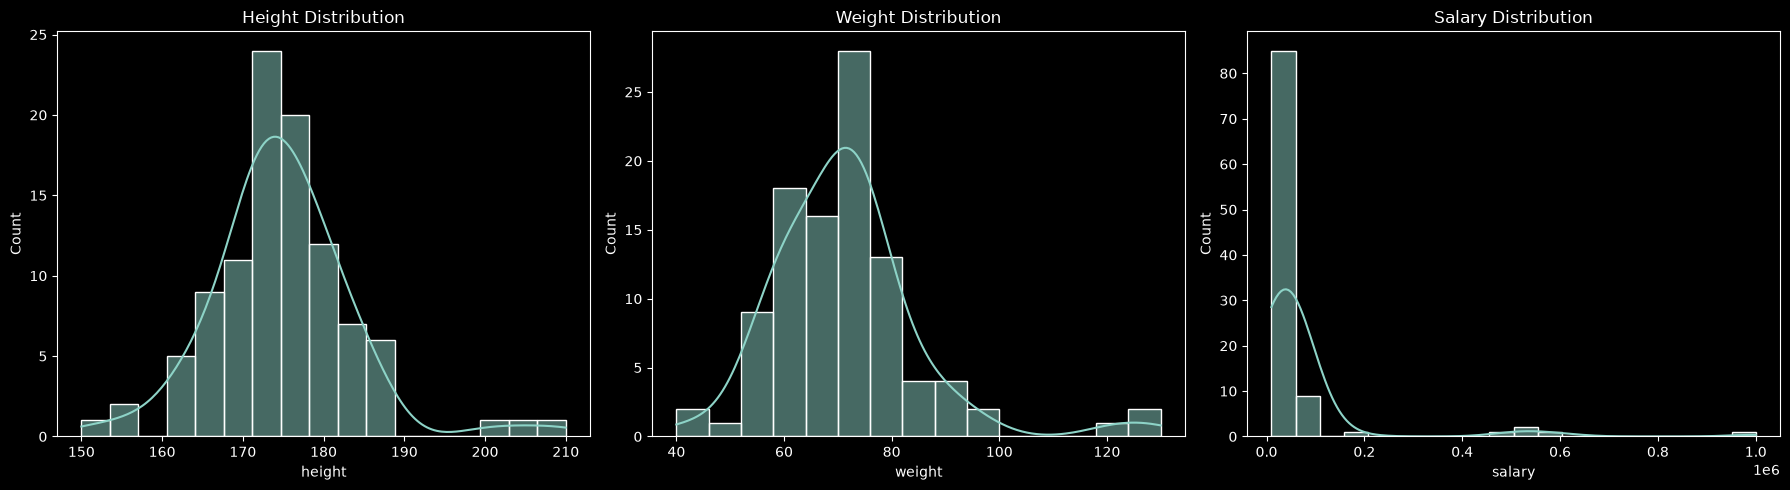

In [13]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

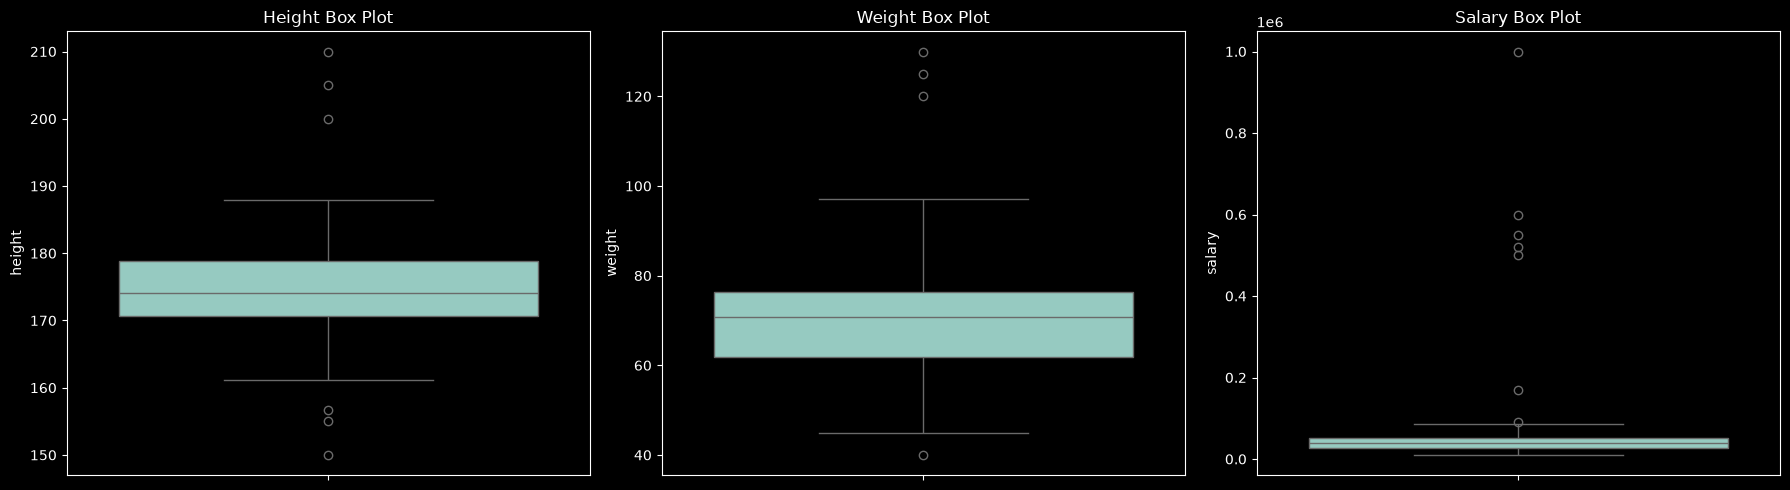

In [14]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

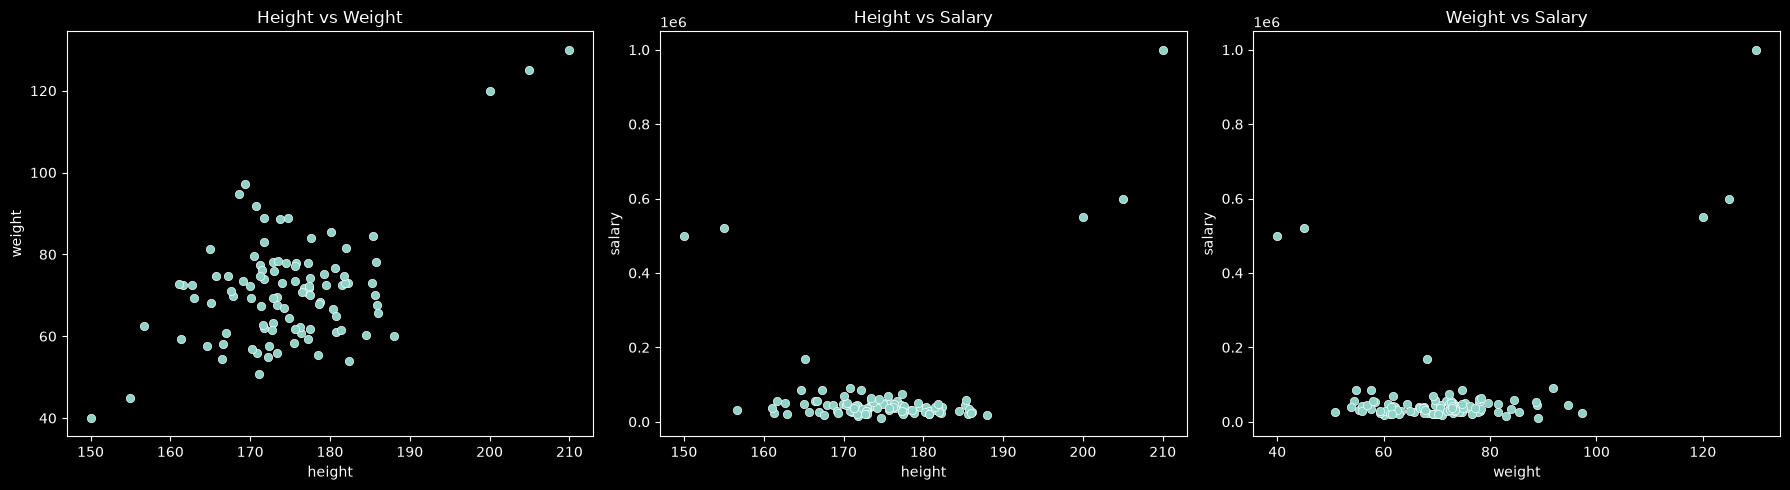

In [15]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [16]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [17]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [18]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [19]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


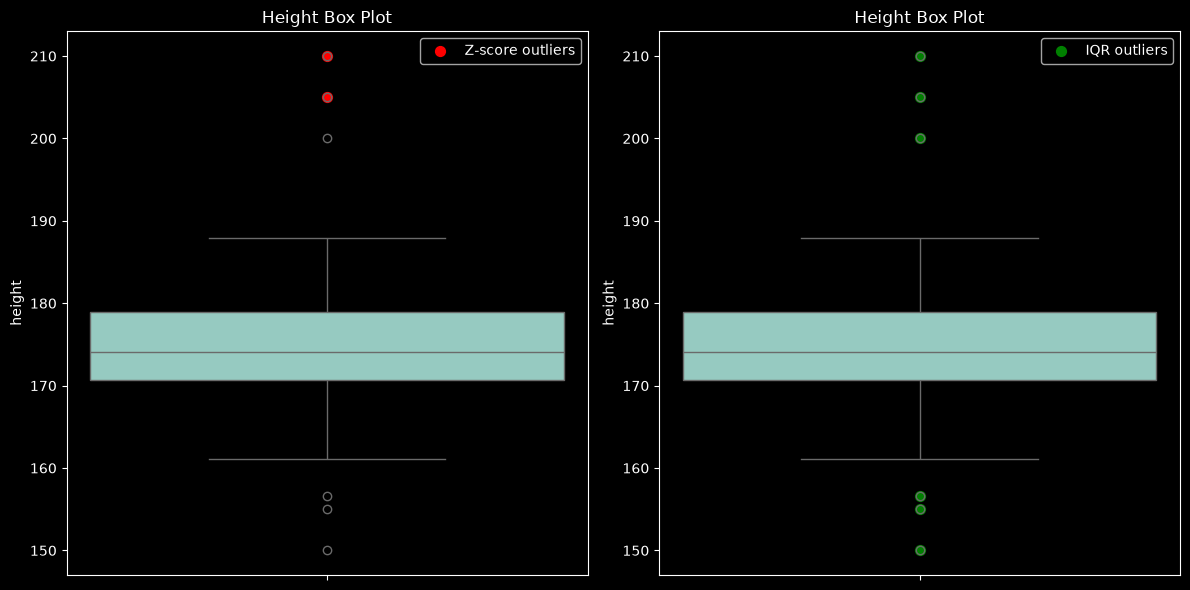

In [20]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [21]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [22]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [23]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [24]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


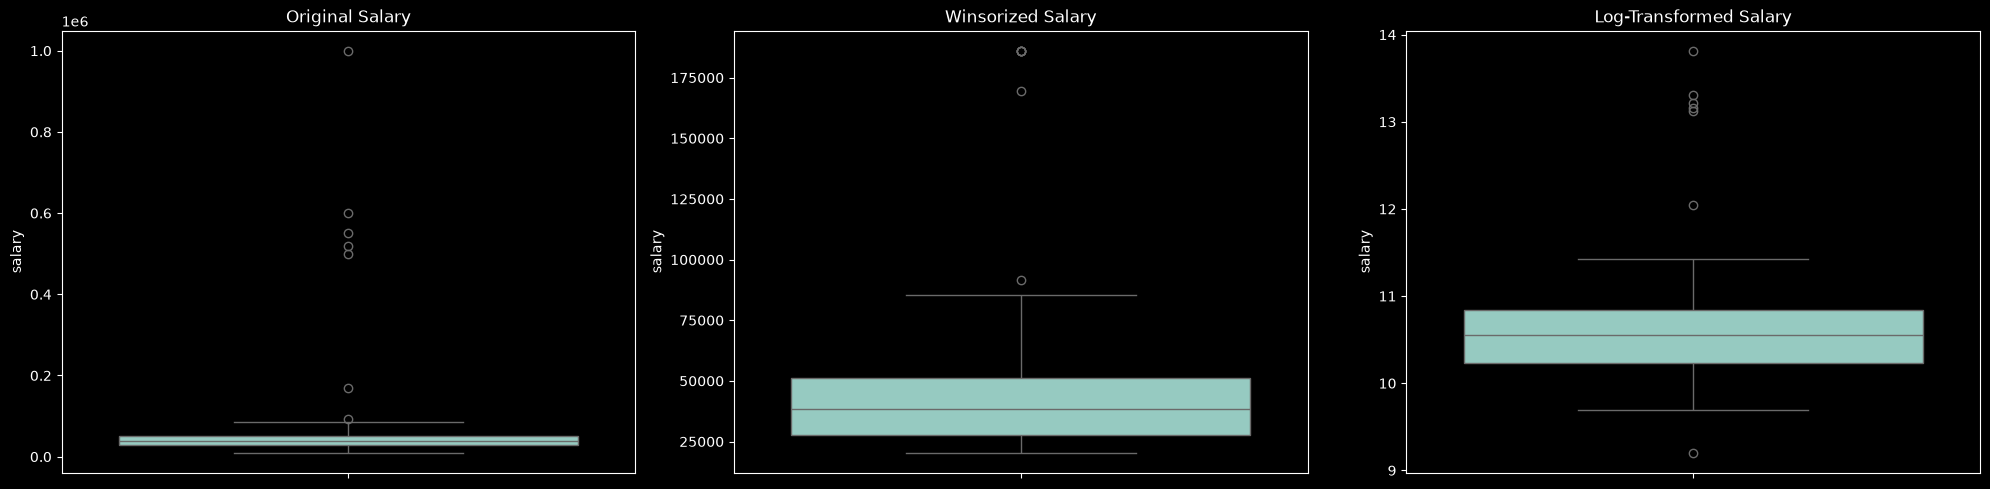

In [25]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [26]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


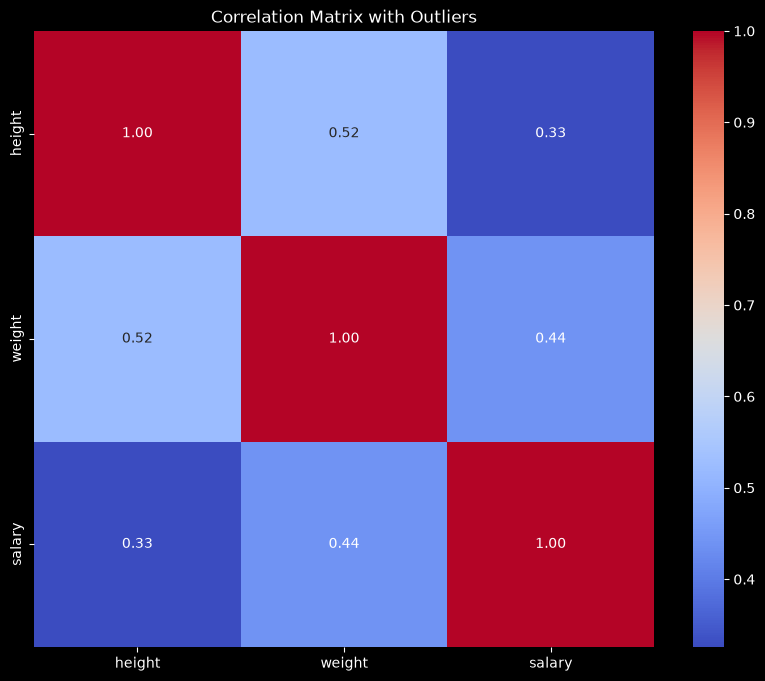

In [27]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


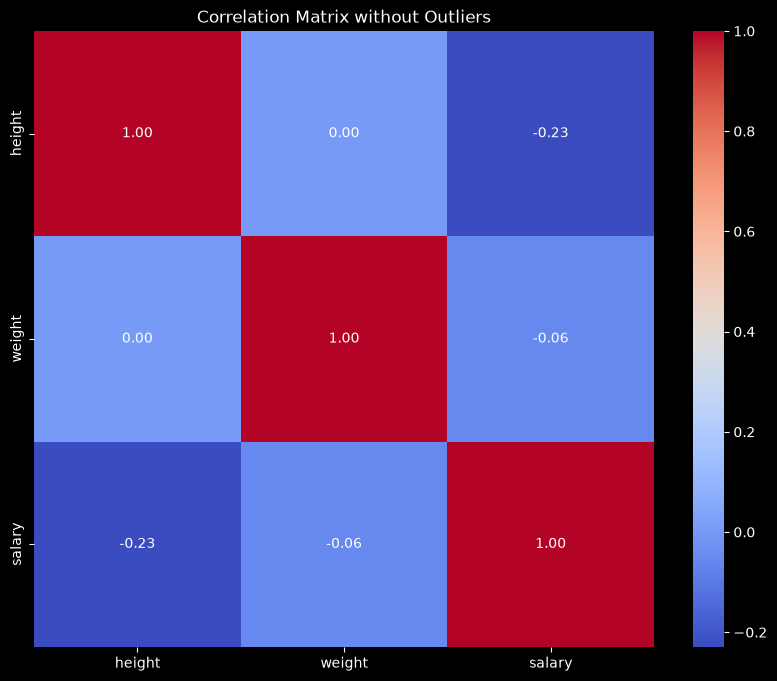

In [28]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [29]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [54]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [62]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            # mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))  #no sqrt required creating mathametical scale isuue resulting 0 outliers
            mahal = (diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [65]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 6 found at indices [84 95 96 97 98 99]


<Figure size 1200x1000 with 0 Axes>

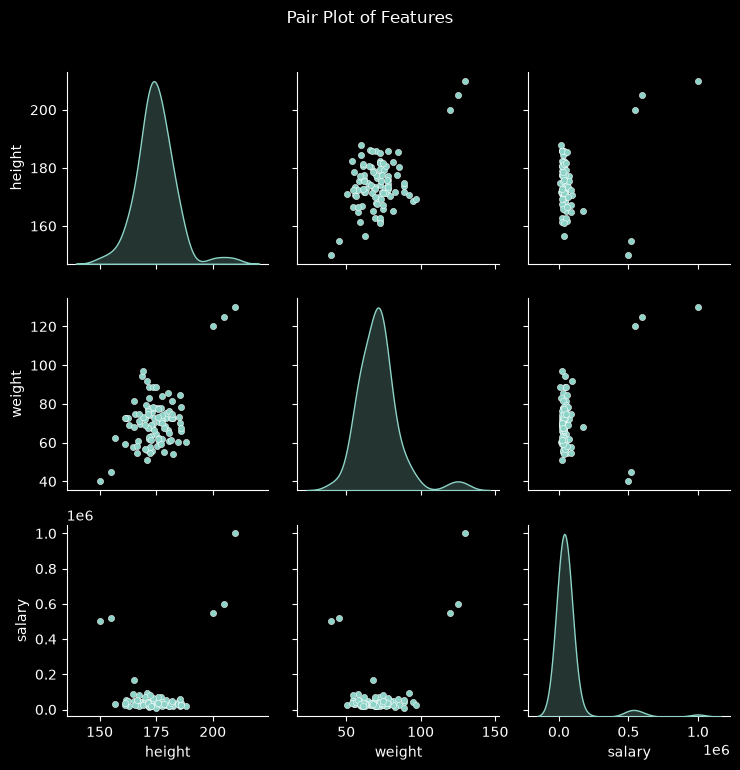

In [66]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

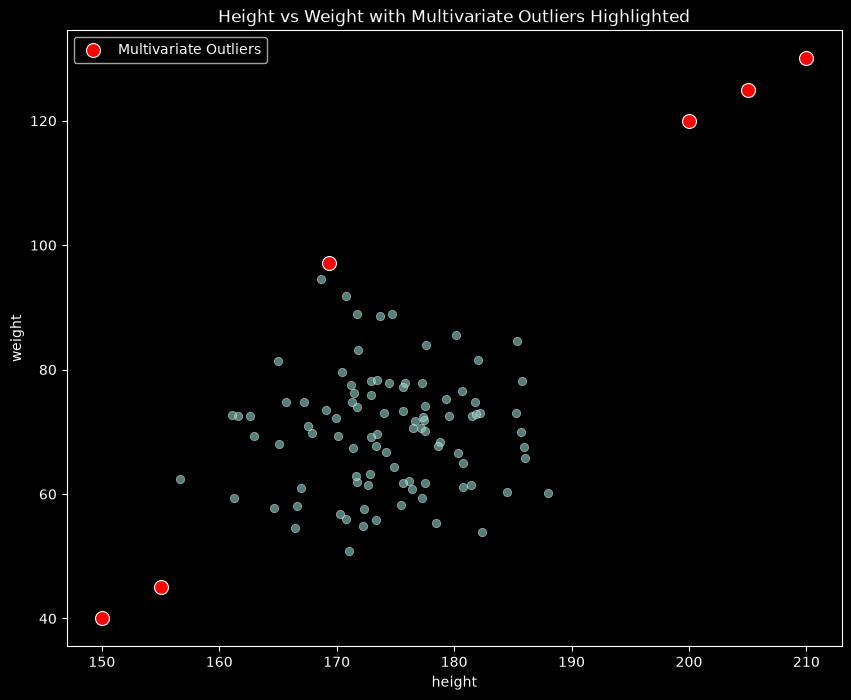

In [67]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


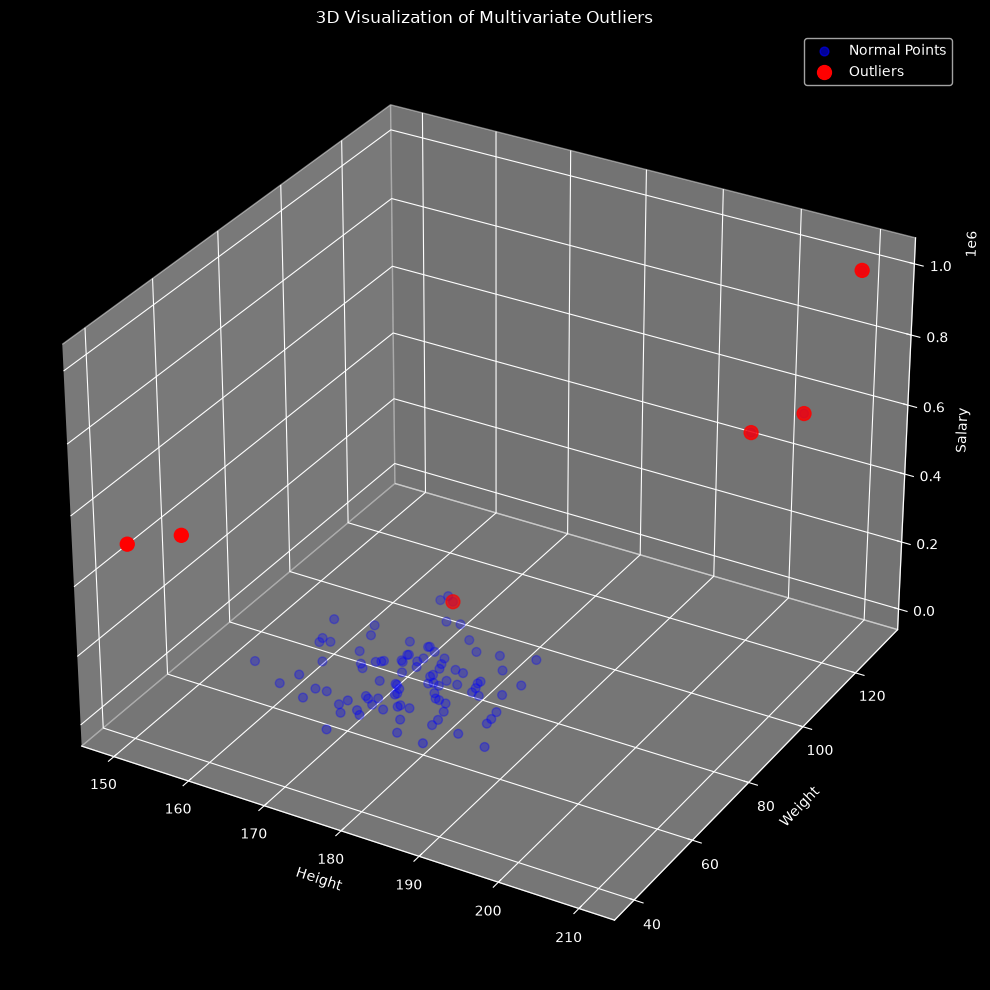

In [68]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


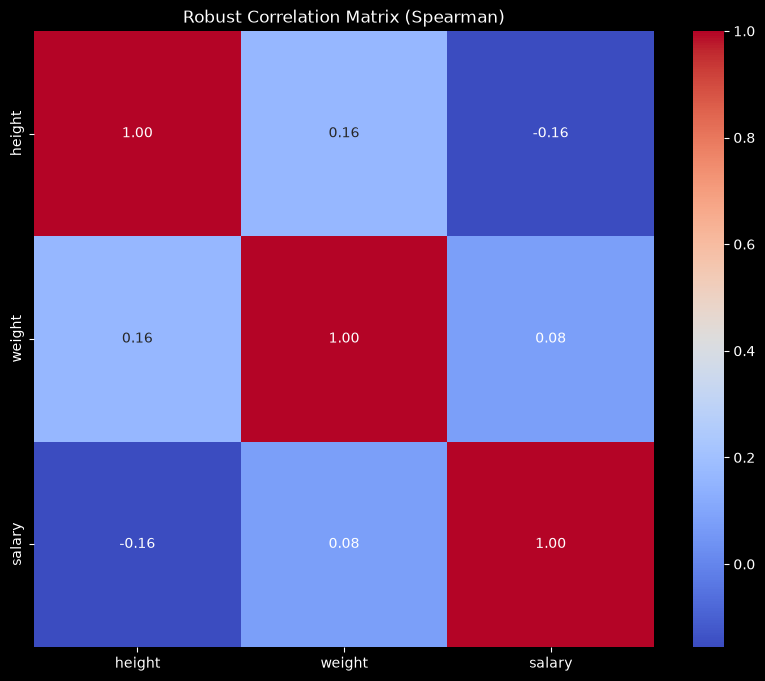

In [69]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [70]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [79]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)

# profile_results_df = pd.DataFrame([
#     profile_feature(df, 'height'),
#     profile_feature(df, 'weight'),
#     profile_feature(df, 'salary')
# ])

# profile_results_df_scaled_standard = pd.DataFrame([
#     profile_feature(df_scaled_standard, 'height'),
#     profile_feature(df_scaled_standard, 'weight'),
#     profile_feature(df_scaled_standard, 'salary')
# ])

# profile_results_df
# profile_results_df_scaled_standard

,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,1.172396e-15,-0.078729,1.005038,-2.824753,4.008615,6.833368,0.934667,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,-8.881784e-17,-0.040124,1.005038,-2.264927,4.227465,6.492392,1.038097,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,5.329071e-17,-0.233995,1.005038,-0.441603,6.767955,7.209557,0.170022,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [80]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

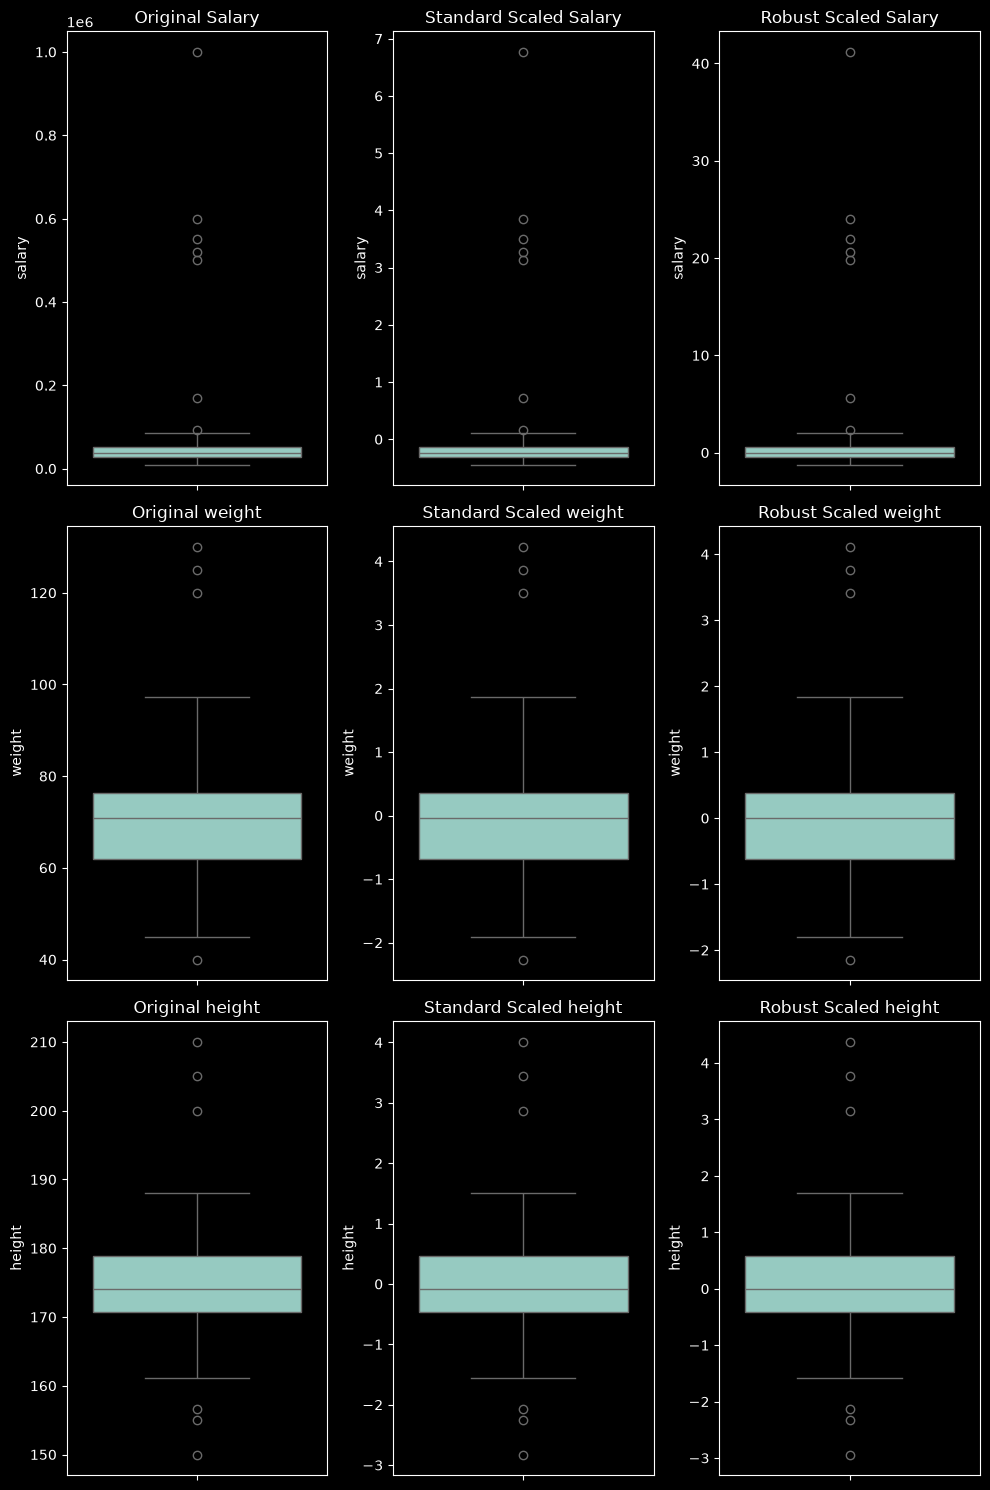

In [104]:
# Compare the scaled distributions
plt.figure(figsize=(10, 15))

plt.subplot(3, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(3, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(3, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')


plt.subplot(3, 3, 4)
sns.boxplot(y=df['weight'])
plt.title('Original weight')

plt.subplot(3, 3, 5)
sns.boxplot(y=df_scaled_standard['weight'])
plt.title('Standard Scaled weight')

plt.subplot(3, 3, 6)
sns.boxplot(y=df_scaled_robust['weight'])
plt.title('Robust Scaled weight')

plt.subplot(3, 3, 7)
sns.boxplot(y=df['height'])
plt.title('Original height')

plt.subplot(3, 3, 8)
sns.boxplot(y=df_scaled_standard['height'])
plt.title('Standard Scaled height')

plt.subplot(3, 3, 9)
sns.boxplot(y=df_scaled_robust['height'])
plt.title('Robust Scaled height')



plt.tight_layout()
plt.show()


In [105]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [106]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.52x + 1.88')

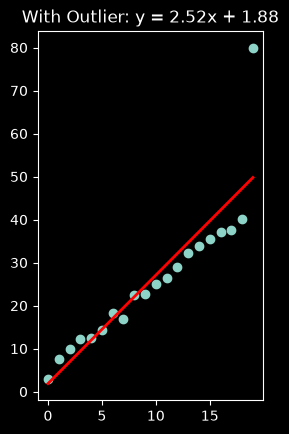

In [107]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


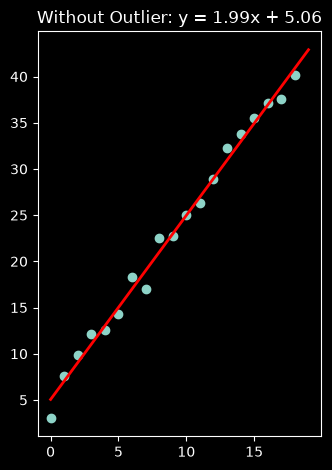

In [108]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [109]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [227]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


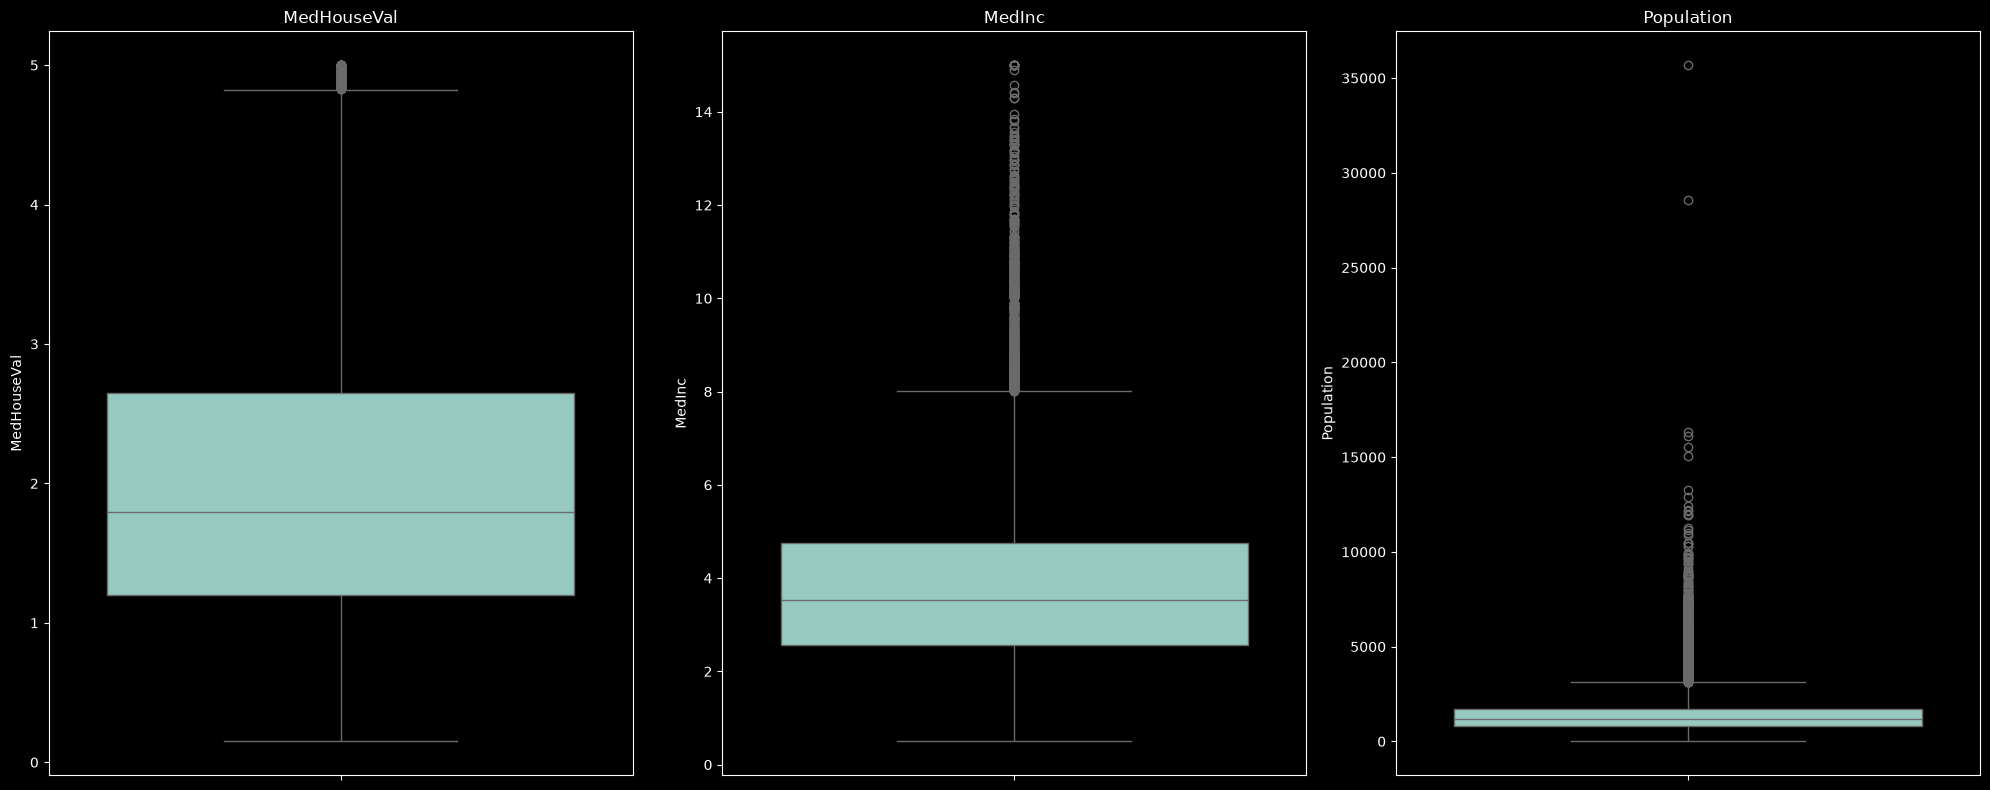

In [111]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
# Hint: Use subplot to organize multiple plots

# Your code here (replace this with your solution)
plt.figure(figsize=(20, 8))

plt.subplot(1,3,1)
sns.boxplot(df['MedHouseVal'])
plt.title('MedHouseVal')

plt.subplot(1,3,2)
sns.boxplot(df['MedInc'])
plt.title('MedInc')

plt.subplot(1,3,3)
sns.boxplot(df['Population'])
plt.title('Population')

plt.tight_layout()
plt.show()

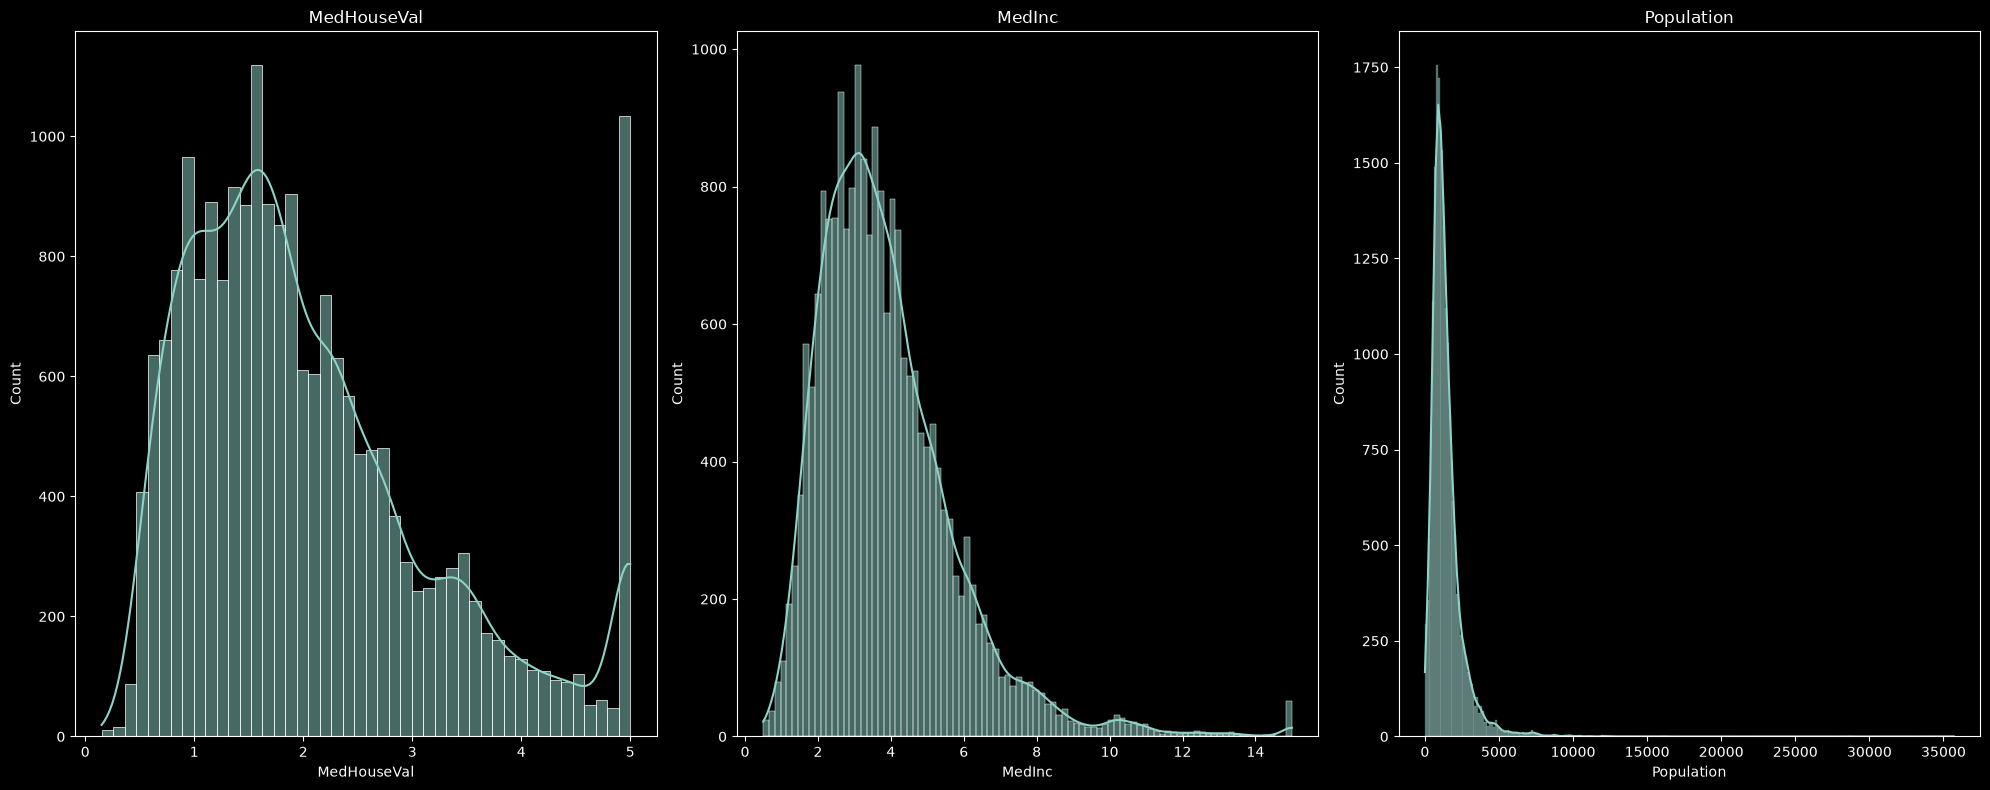

In [112]:
plt.figure(figsize=(20, 8))

plt.subplot(1,3,1)
sns.histplot(df['MedHouseVal'],kde=True, linewidth=0.5)
plt.title('MedHouseVal')

plt.subplot(1,3,2)
sns.histplot(df['MedInc'],kde=True)
plt.title('MedInc')

plt.subplot(1,3,3)
sns.histplot(df['Population'],kde=True)
plt.title('Population')

plt.tight_layout()
plt.show()

In [148]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# # TODO: Implement both Z-score and IQR outlier detection for the MedHouseVal feature


# Q1 = df["MedHouseVal"].quantile(0.25)
# Q3 = df["MedHouseVal"].quantile(0.75)

# Your implementation here
def calculate_percentage(part, total, decimals=2):
    if total == 0:
        return f"{0:.{decimals}f}%"
    percentage = (part / total) * 100
    return f"{percentage:.{decimals}f}%"

# Z-Score
def z_scores_outlier_detection(data, threshold=2.5):
    z_scores = np.abs(stats.zscore(data))
    return(np.where(z_scores > threshold)[0])
print(f"Z- Score:\nTotal data: {df['MedHouseVal'].shape[0]}  --  Outliers: {z_scores_outlier_detection(df['MedHouseVal']).shape[0]} - {calculate_percentage(z_scores_outlier_detection(df['MedHouseVal']).shape[0],df['MedHouseVal'].shape[0])}")
#IQR
factor=1.5
q1, q3 = np.percentile(df['MedHouseVal'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - (factor * iqr)
upper_bound = q3 + (factor * iqr)
MedHouseVal_iqr_outliers=np.where((df['MedHouseVal'] < lower_bound) | (df['MedHouseVal'] > upper_bound))[0]
print(f"\nIQR:\nTotal data: {df['MedHouseVal'].shape[0]}  --  Outliers: {MedHouseVal_iqr_outliers.shape[0]} - {calculate_percentage(MedHouseVal_iqr_outliers.shape[0],df['MedHouseVal'].shape[0])}")



Z- Score:
Total data: 20640  --  Outliers: 1011 - 4.90%

IQR:
Total data: 20640  --  Outliers: 1071 - 5.19%


In [145]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers
# Your implementation here

def outlier_binary_mask_with_IsolationForest(data,contamination=0.05):
    model=IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
    pred=model.fit_predict(data)
    return (pred == -1)

outlier_IF_mask=outlier_binary_mask_with_IsolationForest(X)
print(f"Isolation Forest algorithm:\nTotal Number of Rows: {df.shape[0]}\nTotal Number of Rows with Outliers: {outlier_IF_mask.sum()} -- Top 5% of most unusual row in the dataset ")

Isolation Forest algorithm:
Total Number of Rows: 20640
Total Number of Rows with Outliers: 1032 -- Top 5% of most unusual row in the dataset 


In [169]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'MedInc' to predict 'MedHouseVal'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients

# Your implementation here

z_score_outliers = z_scores_outlier_detection(df['MedHouseVal'])
outlier_IF_mask = outlier_binary_mask_with_IsolationForest(df[['MedHouseVal']])
# Creating a nested dictionary for easy data access
data_dict={
    'all_data' : {
        'x': df[['MedInc']], 
        'y': df['MedHouseVal']},
    
    'z_score_filtered' : {
        'x': df[['MedInc']].drop(index=z_score_outliers),
        'y': df['MedHouseVal'].drop(index=z_score_outliers)},
    
    'Isolation_Forest_filtered' : {
        'x': df[['MedInc']][~outlier_IF_mask],
        'y': df['MedHouseVal'][~outlier_IF_mask]}
}


plt.figure(figsize=(20, 8))

def plot_regression_results(ax, X, y, model, title="Linear Regression"):
    """
    Plots a scatter visualization of data alongside its fit line using an explicit axes object.
    """
    # 1. Plot the actual raw data points
    ax.scatter(X, y, alpha=0.5, color='royalblue', label='Data Points')
    # 2. Plot the trained line of best fit
    y_pred = model.predict(X)
    ax.plot(X, y_pred, color='hotpink', linewidth=2, label='Fit Line')
    
    # 3. Format the chart with professional labeling mechanics
    equation = f"y = {model.coef_.item():.2f}x + {model.intercept_:.2f}"
    ax.set_title(f"{title}\n{equation}", fontsize=12)
    ax.set_xlabel("Predictor Feature (X)")
    ax.set_ylabel("Target (y)")
    ax.legend()

<Figure size 2000x800 with 0 Axes>

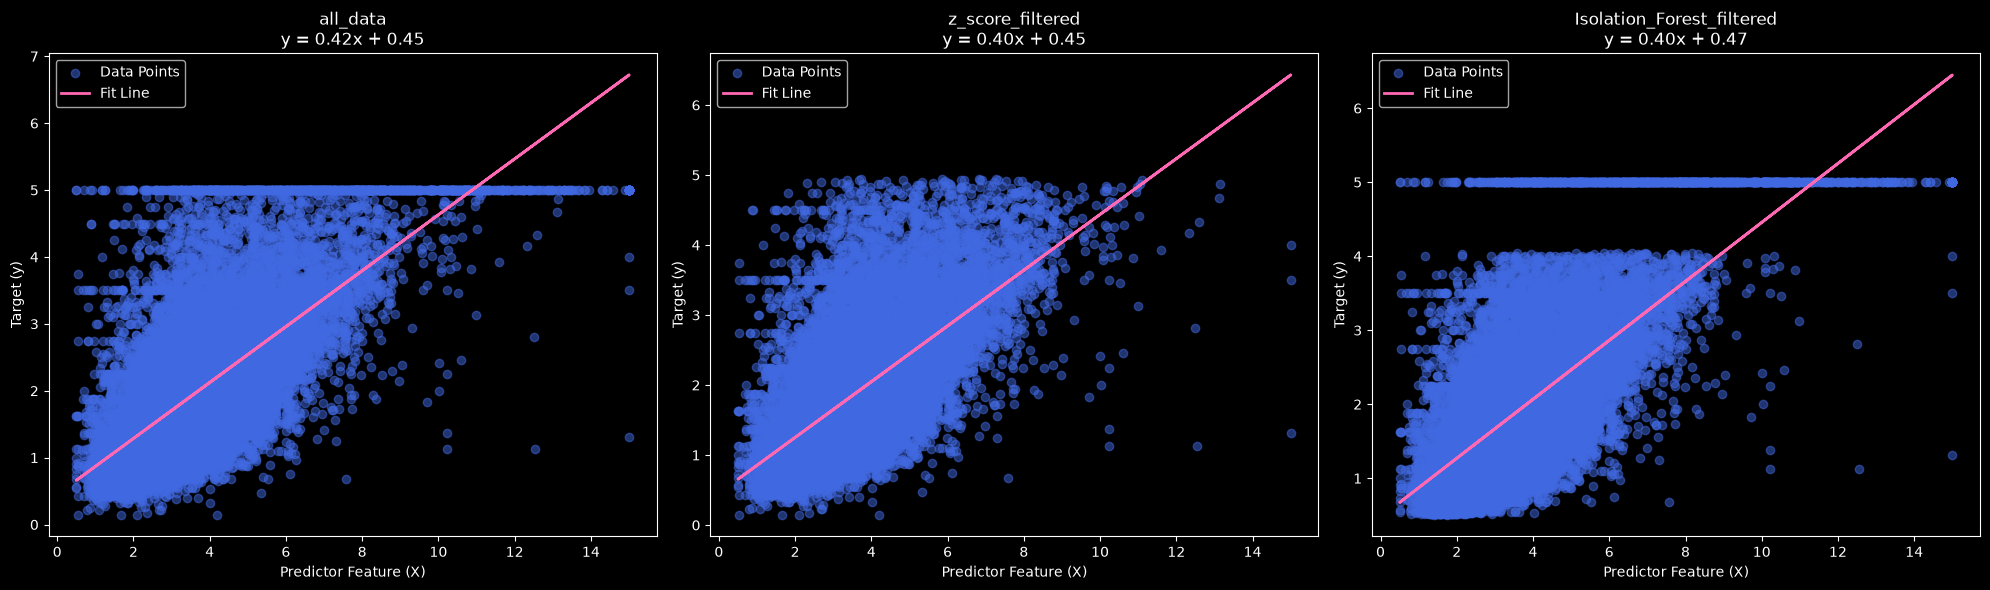

In [170]:
fig, ax = plt.subplots(1,3, figsize=(20, 6))

for i,(data_set, data) in enumerate(data_dict.items()):
    
    X = data['x']
    y = data['y']

    model = LinearRegression().fit(X,y)

    plot_regression_results(ax[i], X=X, y=y, model=model, title=data_set)
    
plt.tight_layout()
plt.show()

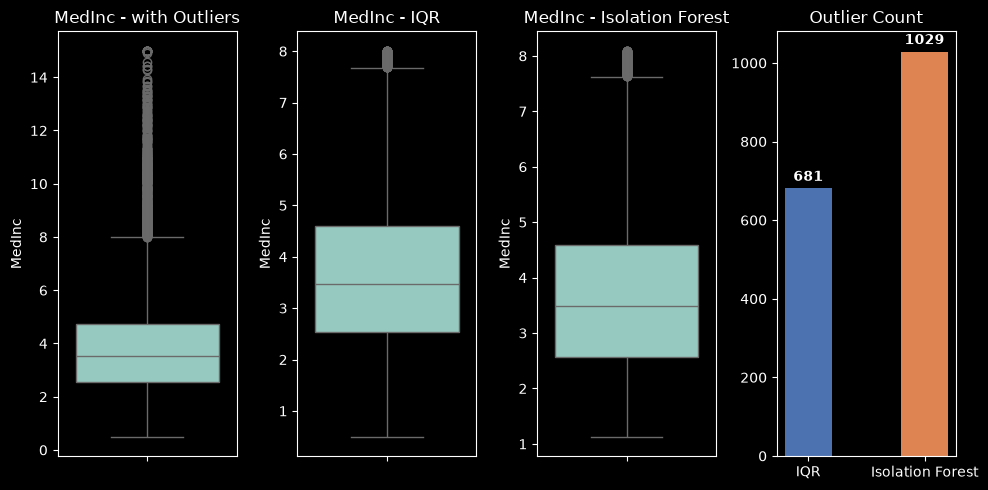

In [213]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

# Your implementation here


def custom_outlier_detection(dataframe, col_name):

    with_iqr = detect_outliers_iqr(dataframe[col_name])
    with_isolation_forest = np.where(outlier_binary_mask_with_IsolationForest(dataframe[[col_name]]))[0]

    data={ 
        'IQR' : with_iqr.shape,
        'Isolation Forest' : with_isolation_forest.shape
            }

    
    labels = ['IQR','Isolation Forest']
    counts = [data.get('IQR')[0], data.get('Isolation Forest')[0]]
        
    plt.figure(figsize=(10,5))
    plt.subplot(1,4,1)
    sns.boxplot(y=dataframe[col_name])
    plt.title(f'{col_name} - with Outliers')

    plt.subplot(1,4,2)
    sns.boxplot(y=dataframe[col_name].drop(index=with_iqr))
    plt.title(f'{col_name} - IQR')

    plt.subplot(1,4,3)
    sns.boxplot(y=dataframe[col_name].drop(index=with_isolation_forest))
    plt.title(f'{col_name} - Isolation Forest')

    plt.subplot(1,4,4)
    bars = plt.bar(labels, counts, color=['#4C72B0', '#DD8452'], width=0.4)
    plt.bar_label(bars, padding=3, weight='bold')
    plt.title('Outlier Count')

    plt.tight_layout()
    plt.show()
    return  { 
        'IQR' : with_iqr,
        'Isolation Forest' : with_isolation_forest
            } 
    # Using pre-built IQR function
    #


xx=custom_outlier_detection(df,'MedInc')


--- AveRooms_log  and Pop_per_Age Statistics ---
       AveRooms_log   Pop_per_Age
count  20640.000000  20640.000000
mean       1.828722     75.434558
std        0.231938    141.636193
min        0.613104      0.150943
25%        1.693911     22.864166
50%        1.829236     40.189904
75%        1.953365     76.526316
max        4.962209   4076.250000


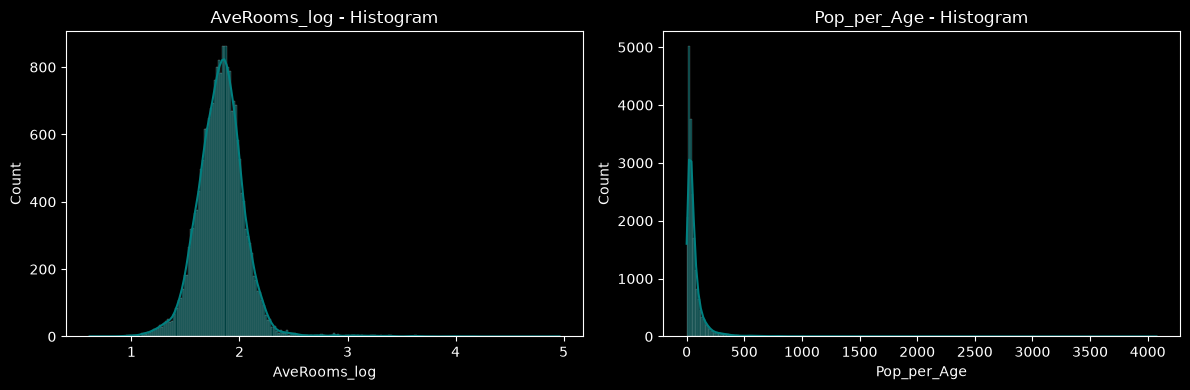

In [234]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

# Your implementation here
n_df=df.copy()
n_df['AveRooms_log']=np.log1p(n_df['AveRooms'])
n_df['Pop_per_Age'] = n_df['Population'] / (n_df['HouseAge'] + 1)

# Execute comparisons

print(f"--- AveRooms_log  and Pop_per_Age Statistics ---")
print(n_df[n_df.columns[-2:]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(n_df['AveRooms_log'], kde=True, ax=axes[0], color="teal")
axes[0].set_title(f"AveRooms_log - Histogram")

sns.histplot(n_df['Pop_per_Age'], kde=True, ax=axes[1], color="teal")
axes[1].set_title(f"Pop_per_Age - Histogram")

plt.tight_layout()
plt.show()




In [241]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

# Your implementation here

def check_mahalanobis_outliers(df, features, significance_level=0.01):
    X=df[features].to_numpy()
    
    cov_mat = np.cov(X, rowvar=False)
    inv_cov_mat = np.linalg.inv(cov_mat)
    var_mean = np.mean(X, axis=0) 

    diff= X-var_mean
    distances = np.diag(np.dot(np.dot(diff, inv_cov_mat), diff.T))

    degree_of_freedom = len(features) #dimensons
    cutoff = stats.chi2.ppf(1 - significance_level, df=degree_of_freedom)

    df["Mahalanobis_Dist"] = distances
    df["Is_Outlier"] = distances > cutoff

    plot_df = df.sample(n=min(len(df), 500), random_state=42)

    g = sns.pairplot(
        plot_df,
        vars=features,
        hue="Is_Outlier",
        palette={True: "crimson", False: "darkcyan"},
        plot_kws={"alpha": 0.6, "edgecolor": "none"},
        diag_kind="kde",
    )
    g.fig.suptitle(
        f"Multivariate Outliers (Cutoff: {cutoff:.2f})", y=1.02, fontsize=14
    )
    plt.show()
    print(f"--- Multivariate Outlier Detection Summary ---")
    print(f"Chi-Squared Cutoff Threshold: {cutoff:.4f}")
    print(df["Is_Outlier"].value_counts())

    return df
    


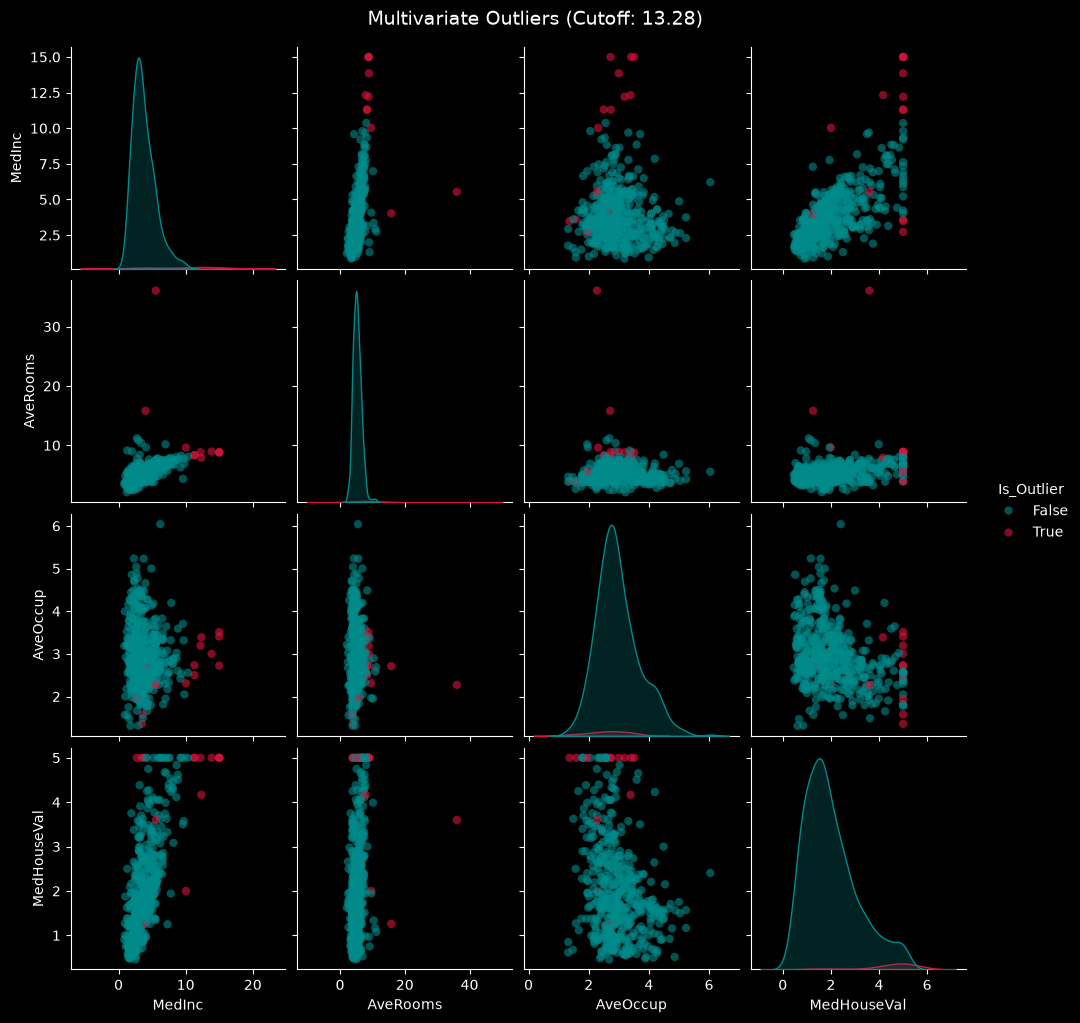

--- Multivariate Outlier Detection Summary ---
Chi-Squared Cutoff Threshold: 13.2767
Is_Outlier
False    20180
True       460
Name: count, dtype: int64


In [242]:
target_features = ['MedInc', 'AveRooms', 'AveOccup', 'MedHouseVal']
df = check_mahalanobis_outliers(df, target_features)

In [264]:
df[['Mahalanobis_Dist','Is_Outlier']].sample(10)

,Mahalanobis_Dist,Is_Outlier
3513,1.355207,False
20144,1.274654,False
2163,1.723652,False
3905,0.171576,False
12052,0.784861,False
6976,0.041772,False
10091,0.614192,False
17094,1.125710,False
12103,1.210996,False
19495,1.106437,False
